In [1]:
from dask.distributed import LocalCluster, Client
cluster = LocalCluster()
client = Client(cluster)

foldername = '/home/edavenport/analysis/yannai-waves/with_spring_2013/shear_prof/'

In [2]:
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 13
import cmocean.cm as cmo
import xarray as xr
from open_tpose import tpose2012to2013
import numpy as np
import xarray as xr

prefix = ['diag_state','diag_surf']
ds_tpose_noTAO = tpose2012to2013(prefix)

ds_tpose_noTAO['XC'] = ds_tpose_noTAO.XC.astype(float)
ds_tpose_noTAO['YC'] = ds_tpose_noTAO.YC.astype(float)
ds_tpose_noTAO['Z'] = ds_tpose_noTAO.Z.astype(float)
ds_tpose_noTAO['XG'] = ds_tpose_noTAO.XG.astype(float)
ds_tpose_noTAO['YG'] = ds_tpose_noTAO.YG.astype(float)

from xmitgcm import open_mdsdataset
data_dir = '/data/SO3/edavenport/tpose6/sep2012/velocity_assim/run_iter22/'
grid_dir = '/data/SO6/TPOSE_diags/tpose6/grid_6/'

offset = 10
num_diags = 30+31+offset #sep, oct + 10 days
itPerFile = 72 # 1 day
intervals = range(itPerFile,itPerFile*num_diags,itPerFile)

prefix = ['diag_state','diag_surf']
ds = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2012-09-01',delta_t=1200)

num_diags = 30+31+offset# nov, dec (starting from nov 10)
itPerFile = 72 # 1 day
intervals = range(itPerFile*offset,itPerFile*num_diags,itPerFile)

data_dir = '/data/SO3/edavenport/tpose6/nov2012/run_iter20/'
ds_new = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2012-11-01',delta_t=1200)

ds_tpose_TAO = xr.concat([ds,ds_new],dim='time')

num_diags = 31+28+offset # jan, feb, (starting from jan 10)
itPerFile = 72 # 1 day
intervals = range(itPerFile*offset,itPerFile*num_diags,itPerFile)

data_dir = '/data/SO3/edavenport/tpose6/jan2013/run_iter14/'
ds_new = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2013-01-01',delta_t=1200)

ds_tpose_TAO = xr.concat([ds_tpose_TAO,ds_new],dim='time')

num_diags = 31+30+31+30 # mar, apr, may, june (starting from jan 10)
itPerFile = 72 # 1 day
intervals = range(itPerFile*offset,itPerFile*num_diags,itPerFile)

data_dir = '/data/SO3/edavenport/tpose6/mar2013/run_iter16/'
ds_new = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2013-03-01',delta_t=1200)

ds_tpose_TAO = xr.concat([ds_tpose_TAO,ds_new],dim='time')

ds_tpose_TAO['XC'] = ds_tpose_TAO.XC.astype(float)
ds_tpose_TAO['YC'] = ds_tpose_TAO.YC.astype(float)
ds_tpose_TAO['Z'] = ds_tpose_TAO.Z.astype(float)
ds_tpose_TAO['XG'] = ds_tpose_TAO.XG.astype(float)
ds_tpose_TAO['YG'] = ds_tpose_TAO.YG.astype(float)

ds_tpose_noTAO = ds_tpose_noTAO.sel(time=slice('2012-09-01','2013-06-29'))

mar2013/diags_daily/
may2013/diags_daily/
jul2013/diags_daily/
sep2013/diags_daily/
nov2013/diags_daily/
Days in 2012-2013: (should be 731)
731


In [3]:
# tpose_ds.ADJetan is t, xc, YG
lat_min = -5
lat_max = 5
lon_min = 170 #170E
lon_max = 260 #100W

ds_tpose_TAO = ds_tpose_TAO.sel(XC=slice(lon_min,lon_max),YC=slice(lat_min,lat_max),XG=slice(lon_min,lon_max),YG=slice(lat_min,lat_max))
ds_tpose_noTAO = ds_tpose_noTAO.sel(XC=slice(lon_min,lon_max),YC=slice(lat_min,lat_max),XG=slice(lon_min,lon_max),YG=slice(lat_min,lat_max))

In [4]:
# lon = 220
lat = 0.0

### Plot Vertical Shear at 5 locations before and after TAO

In [7]:
var_name = 'UVEL'
lat_dim = 'YC'
lon_dim = 'XG'
# 10 panes, row 1 is 5 locations of uvel shear and row 2 is 5 locations of vvel shear
fig, axs = plt.subplots(2,5,figsize=(20,10),sharey=True)
for i,lon in enumerate([190,205,220,235,250]):
    ds_tpose_TAO_shear = ds_tpose_TAO[var_name].sel({lat_dim:lat,lon_dim:lon},method='nearest').mean(dim='time')
    ds_tpose_TAO_shear_std = ds_tpose_TAO[var_name].sel({lat_dim:lat,lon_dim:lon},method='nearest').std(dim='time')
    ds_tpose_noTAO_shear = ds_tpose_noTAO[var_name].sel({lat_dim:lat,lon_dim:lon},method='nearest').mean(dim='time')
    ds_tpose_noTAO_shear_std = ds_tpose_noTAO[var_name].sel({lat_dim:lat,lon_dim:lon},method='nearest').std(dim='time')
    axs[0,i].set_title(f'{var_name} shear at {lat}N°{lon}E°')
    axs[0,i].plot(ds_tpose_TAO_shear,ds_tpose_TAO.Z,color='blue',label='TAO')
    axs[0,i].fill_betweenx(ds_tpose_TAO.Z,ds_tpose_TAO_shear-ds_tpose_TAO_shear_std,ds_tpose_TAO_shear+ds_tpose_TAO_shear_std,color='blue',alpha=0.3)
    axs[0,i].plot(ds_tpose_noTAO_shear,ds_tpose_noTAO.Z,color='orange',label='no TAO',ls='--')
    axs[0,i].fill_betweenx(ds_tpose_noTAO.Z,ds_tpose_noTAO_shear-ds_tpose_noTAO_shear_std,ds_tpose_noTAO_shear+ds_tpose_noTAO_shear_std,color='orange',alpha=0.3)
    axs[0,i].set_xlim(-0.5,1.7)
    axs[0,i].set_xlabel('')

axs[0,0].legend()

lat = 0.0
var_name = 'VVEL'
lat_dim = 'YG'
lon_dim = 'XC'
for i,lon in enumerate([190,205,220,235,250]):
    ds_tpose_TAO_shear = ds_tpose_TAO[var_name].sel({lat_dim:lat,lon_dim:lon},method='nearest').mean(dim='time')
    ds_tpose_TAO_shear_std = ds_tpose_TAO[var_name].sel({lat_dim:lat,lon_dim:lon},method='nearest').std(dim='time')
    ds_tpose_noTAO_shear = ds_tpose_noTAO[var_name].sel({lat_dim:lat,lon_dim:lon},method='nearest').mean(dim='time')
    ds_tpose_noTAO_shear_std = ds_tpose_noTAO[var_name].sel({lat_dim:lat,lon_dim:lon},method='nearest').std(dim='time')
    axs[1,i].set_title(f'{var_name} shear at {lat}N°{lon}E°')
    axs[1,i].plot(ds_tpose_TAO_shear,ds_tpose_TAO.Z,color='blue',label='TAO')
    axs[1,i].fill_betweenx(ds_tpose_TAO.Z,ds_tpose_TAO_shear-ds_tpose_TAO_shear_std,ds_tpose_TAO_shear+ds_tpose_TAO_shear_std,color='blue',alpha=0.3)
    axs[1,i].plot(ds_tpose_noTAO_shear,ds_tpose_noTAO.Z,color='orange',label='no TAO',ls='--')
    axs[1,i].fill_betweenx(ds_tpose_noTAO.Z,ds_tpose_noTAO_shear-ds_tpose_noTAO_shear_std,ds_tpose_noTAO_shear+ds_tpose_noTAO_shear_std,color='orange',alpha=0.3)
    axs[1,i].set_xlim(-0.5,0.5)
    axs[1,i].set_xlabel('Shear (1/s)')

axs[1,0].legend()

for ax in axs.flatten():
    ax.axvline(0,color='black',lw=0.5)

plt.tight_layout()
plt.savefig(foldername + 'vel_comparison.png',dpi=300)

In [ ]:
var_name = 'UVEL'
lat_dim = 'YC'
lon_dim = 'XG'
# 10 panes, row 1 is 5 locations of uvel shear and row 2 is 5 locations of vvel shear
fig, axs = plt.subplots(2,5,figsize=(20,10),sharey=True)
for i,lon in enumerate([190,205,220,235,250]):
    ds_tpose_TAO_shear = ds_tpose_TAO[var_name].sel({lat_dim:lat,lon_dim:lon},method='nearest').mean(dim='time')
    ds_tpose_TAO_shear_std = ds_tpose_TAO[var_name].sel({lat_dim:lat,lon_dim:lon},method='nearest').std(dim='time')
    ds_tpose_noTAO_shear = ds_tpose_noTAO[var_name].sel({lat_dim:lat,lon_dim:lon},method='nearest').mean(dim='time')
    ds_tpose_noTAO_shear_std = ds_tpose_noTAO[var_name].sel({lat_dim:lat,lon_dim:lon},method='nearest').std(dim='time')
    axs[0,i].set_title(f'{var_name} shear at {lat}N°{lon}E°')
    axs[0,i].plot(ds_tpose_TAO_shear,ds_tpose_TAO.Z,color='blue',label='TAO')
    axs[0,i].fill_betweenx(ds_tpose_TAO.Z,ds_tpose_TAO_shear-ds_tpose_TAO_shear_std,ds_tpose_TAO_shear+ds_tpose_TAO_shear_std,color='blue',alpha=0.3)
    axs[0,i].plot(ds_tpose_noTAO_shear,ds_tpose_noTAO.Z,color='orange',label='no TAO',ls='--')
    axs[0,i].fill_betweenx(ds_tpose_noTAO.Z,ds_tpose_noTAO_shear-ds_tpose_noTAO_shear_std,ds_tpose_noTAO_shear+ds_tpose_noTAO_shear_std,color='orange',alpha=0.3)
    axs[0,i].set_xlim(-0.5,1.7)
    axs[0,i].set_xlabel('')

axs[0,0].legend()

lat = 0.0
var_name = 'VVEL'
lat_dim = 'YG'
lon_dim = 'XC'
for i,lon in enumerate([190,205,220,235,250]):
    ds_tpose_TAO_shear = ds_tpose_TAO[var_name].sel({lat_dim:lat,lon_dim:lon},method='nearest').mean(dim='time')
    ds_tpose_TAO_shear_std = ds_tpose_TAO[var_name].sel({lat_dim:lat,lon_dim:lon},method='nearest').std(dim='time')
    ds_tpose_noTAO_shear = ds_tpose_noTAO[var_name].sel({lat_dim:lat,lon_dim:lon},method='nearest').mean(dim='time')
    ds_tpose_noTAO_shear_std = ds_tpose_noTAO[var_name].sel({lat_dim:lat,lon_dim:lon},method='nearest').std(dim='time')
    axs[1,i].set_title(f'{var_name} shear at {lat}N°{lon}E°')
    axs[1,i].plot(ds_tpose_TAO_shear,ds_tpose_TAO.Z,color='blue',label='TAO')
    axs[1,i].fill_betweenx(ds_tpose_TAO.Z,ds_tpose_TAO_shear-ds_tpose_TAO_shear_std,ds_tpose_TAO_shear+ds_tpose_TAO_shear_std,color='blue',alpha=0.3)
    axs[1,i].plot(ds_tpose_noTAO_shear,ds_tpose_noTAO.Z,color='orange',label='no TAO',ls='--')
    axs[1,i].fill_betweenx(ds_tpose_noTAO.Z,ds_tpose_noTAO_shear-ds_tpose_noTAO_shear_std,ds_tpose_noTAO_shear+ds_tpose_noTAO_shear_std,color='orange',alpha=0.3)
    axs[1,i].set_xlim(-0.5,0.5)
    axs[1,i].set_xlabel('Shear (1/s)')

axs[1,0].legend()

for ax in axs.flatten():
    ax.axvline(0,color='black',lw=0.5)
    ax.set_ylim(-750,0)

plt.tight_layout()
plt.savefig(foldername + 'vel_comparison_750m.png',dpi=300)

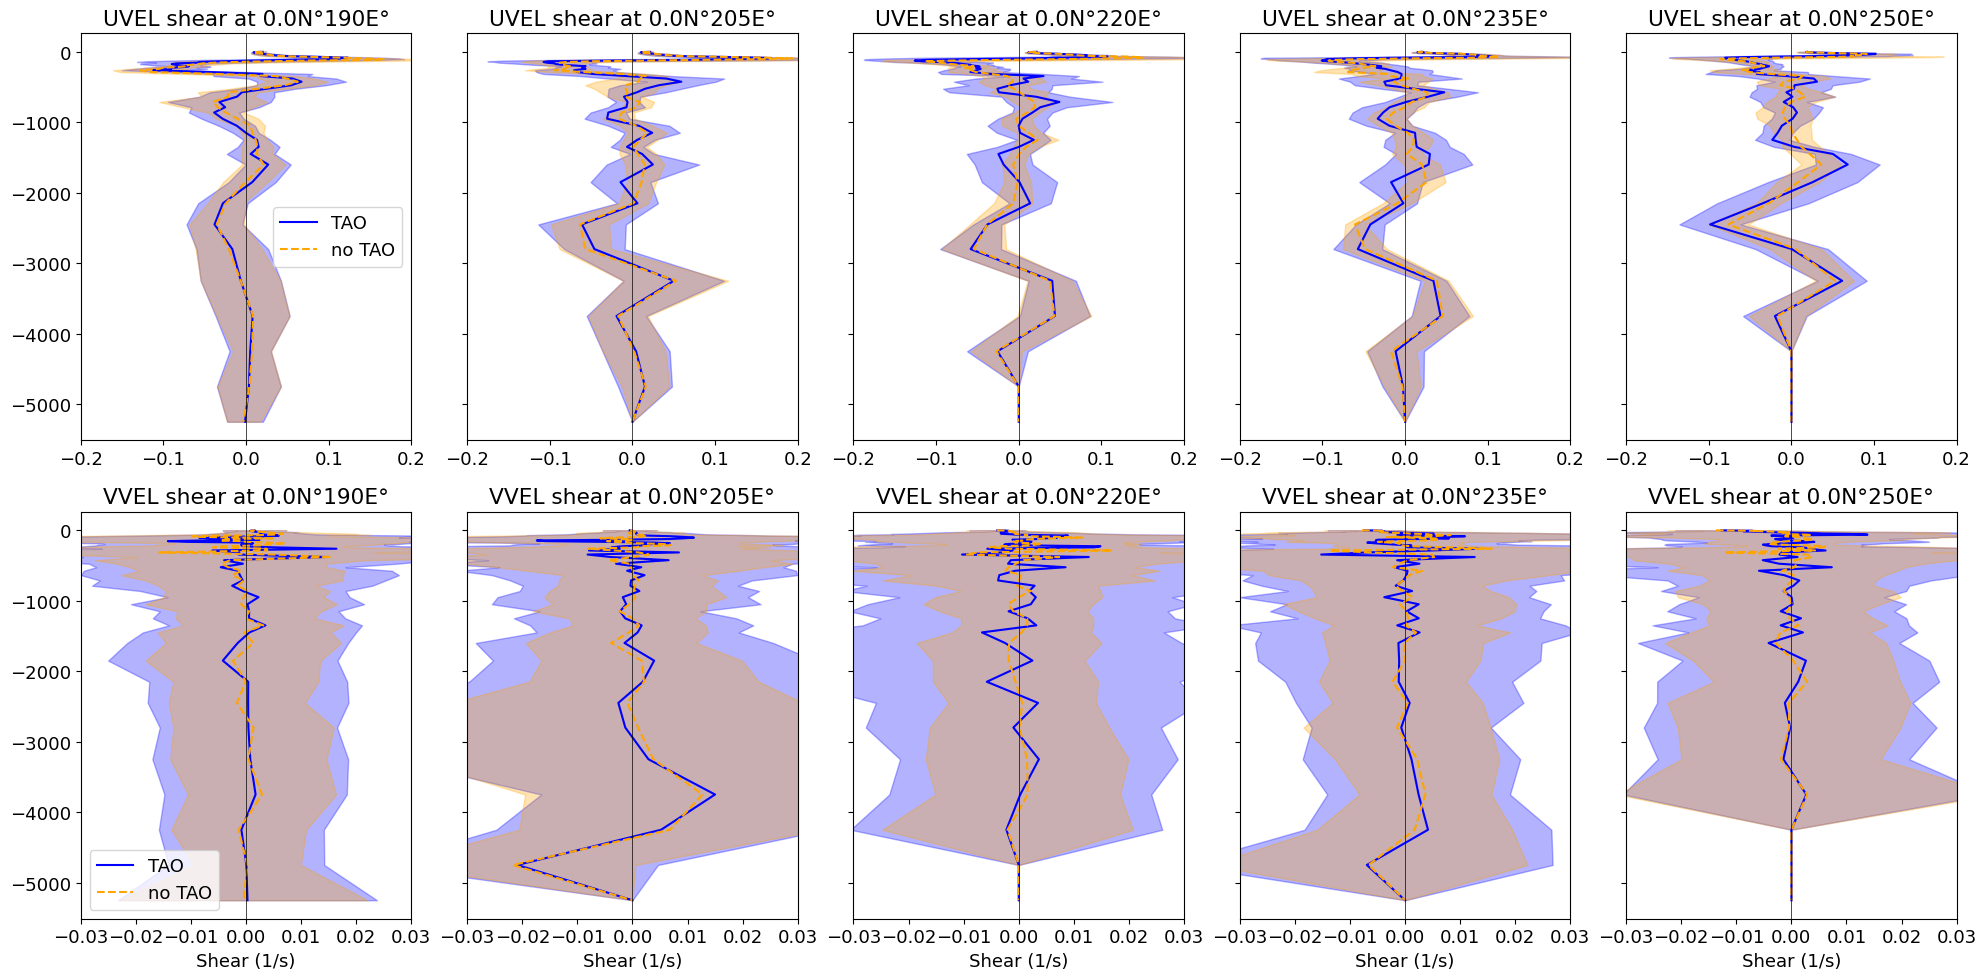

In [5]:
var_name = 'UVEL'
lat_dim = 'YC'
lon_dim = 'XG'
# 10 panes, row 1 is 5 locations of uvel shear and row 2 is 5 locations of vvel shear
fig, axs = plt.subplots(2,5,figsize=(20,10),sharey=True)
for i,lon in enumerate([190,205,220,235,250]):
    ds_tpose_TAO_shear = ds_tpose_TAO[var_name].sel({lat_dim:lat,lon_dim:lon},method='nearest').diff(dim='Z').mean(dim='time')
    ds_tpose_TAO_shear_std = ds_tpose_TAO[var_name].sel({lat_dim:lat,lon_dim:lon},method='nearest').diff(dim='Z').std(dim='time')
    ds_tpose_noTAO_shear = ds_tpose_noTAO[var_name].sel({lat_dim:lat,lon_dim:lon},method='nearest').diff(dim='Z').mean(dim='time')
    ds_tpose_noTAO_shear_std = ds_tpose_noTAO[var_name].sel({lat_dim:lat,lon_dim:lon},method='nearest').diff(dim='Z').std(dim='time')
    axs[0,i].set_title(f'{var_name} shear at {lat}N°{lon}E°')
    axs[0,i].plot(ds_tpose_TAO_shear,ds_tpose_TAO.Z[:-1],color='blue',label='TAO')
    axs[0,i].fill_betweenx(ds_tpose_TAO.Z[:-1],ds_tpose_TAO_shear-ds_tpose_TAO_shear_std,ds_tpose_TAO_shear+ds_tpose_TAO_shear_std,color='blue',alpha=0.3)
    axs[0,i].plot(ds_tpose_noTAO_shear,ds_tpose_noTAO.Z[:-1],color='orange',label='no TAO',ls='--')
    axs[0,i].fill_betweenx(ds_tpose_noTAO.Z[:-1],ds_tpose_noTAO_shear-ds_tpose_noTAO_shear_std,ds_tpose_noTAO_shear+ds_tpose_noTAO_shear_std,color='orange',alpha=0.3)
    axs[0,i].set_xlim(-0.2,0.2)
    axs[0,i].set_xlabel('')

axs[0,0].legend()

lat = 0.0
var_name = 'VVEL'
lat_dim = 'YG'
lon_dim = 'XC'
for i,lon in enumerate([190,205,220,235,250]):
    ds_tpose_TAO_shear = ds_tpose_TAO[var_name].sel({lat_dim:lat,lon_dim:lon},method='nearest').diff(dim='Z').mean(dim='time')
    ds_tpose_TAO_shear_std = ds_tpose_TAO[var_name].sel({lat_dim:lat,lon_dim:lon},method='nearest').diff(dim='Z').std(dim='time')
    ds_tpose_noTAO_shear = ds_tpose_noTAO[var_name].sel({lat_dim:lat,lon_dim:lon},method='nearest').diff(dim='Z').mean(dim='time')
    ds_tpose_noTAO_shear_std = ds_tpose_noTAO[var_name].sel({lat_dim:lat,lon_dim:lon},method='nearest').diff(dim='Z').std(dim='time')
    axs[1,i].set_title(f'{var_name} shear at {lat}N°{lon}E°')
    axs[1,i].plot(ds_tpose_TAO_shear,ds_tpose_TAO.Z[:-1],color='blue',label='TAO')
    axs[1,i].fill_betweenx(ds_tpose_TAO.Z[:-1],ds_tpose_TAO_shear-ds_tpose_TAO_shear_std,ds_tpose_TAO_shear+ds_tpose_TAO_shear_std,color='blue',alpha=0.3)
    axs[1,i].plot(ds_tpose_noTAO_shear,ds_tpose_noTAO.Z[:-1],color='orange',label='no TAO',ls='--')
    axs[1,i].fill_betweenx(ds_tpose_noTAO.Z[:-1],ds_tpose_noTAO_shear-ds_tpose_noTAO_shear_std,ds_tpose_noTAO_shear+ds_tpose_noTAO_shear_std,color='orange',alpha=0.3)
    axs[1,i].set_xlim(-0.03,0.03)
    axs[1,i].set_xlabel('Shear (1/s)')

axs[1,0].legend()

for ax in axs.flatten():
    ax.axvline(0,color='black',lw=0.5)

plt.tight_layout()
plt.savefig(foldername + 'shear_comparison.png',dpi=300)

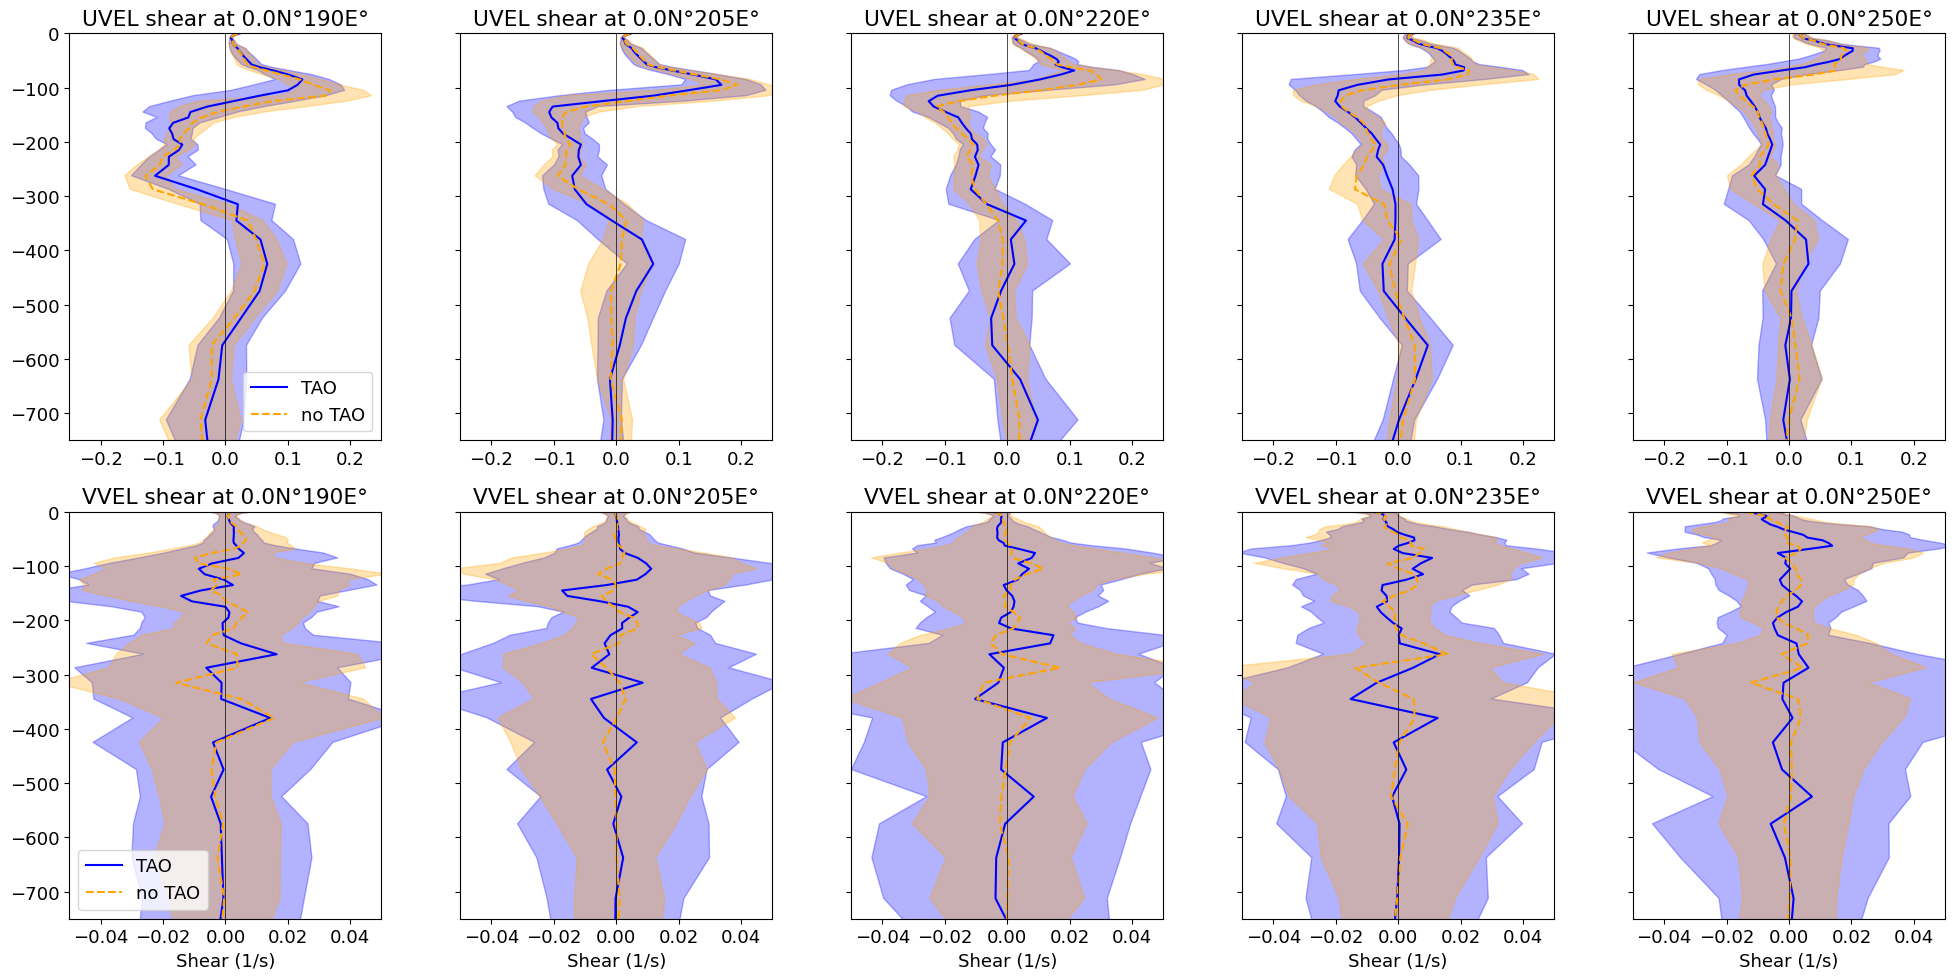

In [6]:
# 10 panes, row 1 is 5 locations of uvel shear and row 2 is 5 locations of vvel shear
var_name = 'UVEL'
lat_dim = 'YC'
lon_dim = 'XG'
fig, axs = plt.subplots(2,5,figsize=(20,10),sharey=True)
for i,lon in enumerate([190,205,220,235,250]):
    ds_tpose_TAO_shear = ds_tpose_TAO[var_name].sel({lat_dim:lat,lon_dim:lon},method='nearest').diff(dim='Z').mean(dim='time')
    ds_tpose_TAO_shear_std = ds_tpose_TAO[var_name].sel({lat_dim:lat,lon_dim:lon},method='nearest').diff(dim='Z').std(dim='time')
    ds_tpose_noTAO_shear = ds_tpose_noTAO[var_name].sel({lat_dim:lat,lon_dim:lon},method='nearest').diff(dim='Z').mean(dim='time')
    ds_tpose_noTAO_shear_std = ds_tpose_noTAO[var_name].sel({lat_dim:lat,lon_dim:lon},method='nearest').diff(dim='Z').std(dim='time')
    axs[0,i].set_title(f'{var_name} shear at {lat}N°{lon}E°')
    axs[0,i].plot(ds_tpose_TAO_shear,ds_tpose_TAO.Z[:-1],color='blue',label='TAO')
    axs[0,i].fill_betweenx(ds_tpose_TAO.Z[:-1],ds_tpose_TAO_shear-ds_tpose_TAO_shear_std,ds_tpose_TAO_shear+ds_tpose_TAO_shear_std,color='blue',alpha=0.3)
    axs[0,i].plot(ds_tpose_noTAO_shear,ds_tpose_noTAO.Z[:-1],color='orange',label='no TAO',ls='--')
    axs[0,i].fill_betweenx(ds_tpose_noTAO.Z[:-1],ds_tpose_noTAO_shear-ds_tpose_noTAO_shear_std,ds_tpose_noTAO_shear+ds_tpose_noTAO_shear_std,color='orange',alpha=0.3)
    axs[0,i].set_xlim(-0.25,0.25)
    axs[0,i].set_xlabel('')

axs[0,0].legend()

lat = 0.0
var_name = 'VVEL'
lat_dim = 'YG'
lon_dim = 'XC'
for i,lon in enumerate([190,205,220,235,250]):
    ds_tpose_TAO_shear = ds_tpose_TAO[var_name].sel({lat_dim:lat,lon_dim:lon},method='nearest').diff(dim='Z').mean(dim='time')
    ds_tpose_TAO_shear_std = ds_tpose_TAO[var_name].sel({lat_dim:lat,lon_dim:lon},method='nearest').diff(dim='Z').std(dim='time')
    ds_tpose_noTAO_shear = ds_tpose_noTAO[var_name].sel({lat_dim:lat,lon_dim:lon},method='nearest').diff(dim='Z').mean(dim='time')
    ds_tpose_noTAO_shear_std = ds_tpose_noTAO[var_name].sel({lat_dim:lat,lon_dim:lon},method='nearest').diff(dim='Z').std(dim='time')
    axs[1,i].set_title(f'{var_name} shear at {lat}N°{lon}E°')
    axs[1,i].plot(ds_tpose_TAO_shear,ds_tpose_TAO.Z[:-1],color='blue',label='TAO')
    axs[1,i].fill_betweenx(ds_tpose_TAO.Z[:-1],ds_tpose_TAO_shear-ds_tpose_TAO_shear_std,ds_tpose_TAO_shear+ds_tpose_TAO_shear_std,color='blue',alpha=0.3)
    axs[1,i].plot(ds_tpose_noTAO_shear,ds_tpose_noTAO.Z[:-1],color='orange',label='no TAO',ls='--')
    axs[1,i].fill_betweenx(ds_tpose_noTAO.Z[:-1],ds_tpose_noTAO_shear-ds_tpose_noTAO_shear_std,ds_tpose_noTAO_shear+ds_tpose_noTAO_shear_std,color='orange',alpha=0.3)
    axs[1,i].set_xlim(-0.05,0.05)
    axs[1,i].set_xlabel('Shear (1/s)')

axs[1,0].legend()

for ax in axs.flatten():
    ax.axvline(0,color='black',lw=0.5)
    ax.set_ylim(-750,0)

plt.tight_layout()
plt.savefig(foldername + 'shear_comparison_750m.png',dpi=300)

In [27]:
client.shutdown()
cluster.close()
client.close()

: 